### **Objective**
Learn how to build an Agentic RAG pipeline from scratch, integrating local data sources and web scraping to generate context-aware responses to user queries.

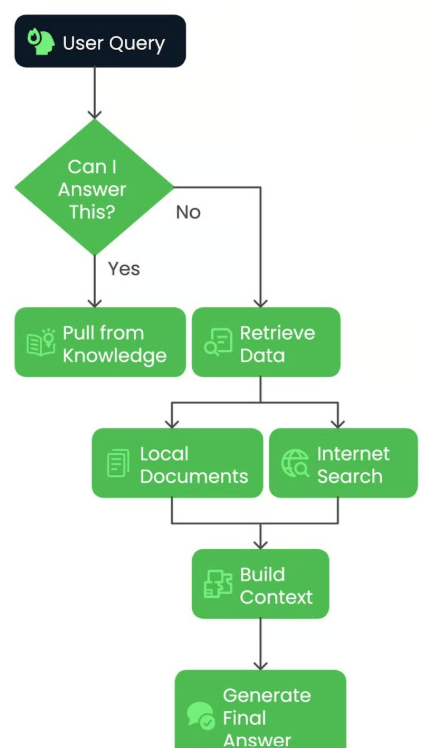

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!pip install -q nest_asyncio

import nest_asyncio
nest_asyncio.apply()

In [ ]:
!pip install -q python-dotenv
!pip install -q langchain-community
!pip install -q pypdf  # needed by PyPDFLoader
!pip install -q langchain
!pip install -q langchain-huggingface
!pip install -q sentence-transformers  # needed by HuggingFaceEmbeddings
!pip install -q langchain-groq
!pip install -q langchain_groq
!pip install -q langchain-text-splitters
!pip install -q faiss-cpu  # needed for FAISS vectorstore
!pip install -q 'crewai[tools]'  # gives you crewai + crewai_tools

In [ ]:
import os # Provides operating system interface utilities.
import getpass
import dotenv # Loads environment variables
from langchain_community.vectorstores import FAISS  # Vector store for similarity search and retrieval.
from langchain_community.document_loaders import PyPDFLoader  # Extracts text content from PDF documents.
from langchain_groq import ChatGroq # Chat interface powered by Groq hardware acceleration.
from langchain_text_splitters import RecursiveCharacterTextSplitter # Splits text into manageable chunks recursively.
from langchain_huggingface.embeddings import HuggingFaceEmbeddings  # Generates text embeddings using HuggingFace models.
from crewai_tools import SerperDevTool, ScrapeWebsiteTool  # Tool for performing web searches.
from crewai import Agent, Task, Crew, LLM # Orchestrates agents and tasks for coordinated workflows.
import asyncio

In [ ]:
if "GROQ_API_KEY" not in os.environ:
  os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your Groq API key: ")
if "SERPER_API_KEY" not in os.environ:
  os.environ["SERPER_API_KEY"] = getpass.getpass("Enter your SERPER_ API key: ")
if "GEMINI" not in os.environ:
  os.environ["GEMINI"] = getpass.getpass("Enter your GEMINI API key: ")

In [ ]:
GEMINI=os.getenv("GEMINI")

In [ ]:
# For general tasks like routing and generating answers.
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0,
    max_tokens=500,
    timeout=None,
    max_retries=2,
)

# For the web-scraping agent, as it needs a slightly different configuration (like temperature for more creative outputs).
crew_llm = LLM(
    model="gemini/gemini-3.5-flash-lite",#"gemini/gemini-3.6-flash",
    api_key=GEMINI,
    max_tokens=500,
    temperature=0.7
)

### **Adding the Decision Maker**

In [ ]:
def check_local_knowledge(query, context):
    """Router function to determine if we can answer from local knowledge"""
    prompt = '''Role: Question-Answering Assistant
Task: Determine whether the system can answer the user's question based on the provided text.
Instructions:
    - Analyze the text and identify if it contains the necessary information to answer the user's question.
    - Provide a clear and concise response indicating whether the system can answer the question or not.
    - Your response should include only a single word. Nothing else, no other text, information, header/footer.
Output Format:
    - Answer: Yes/No
Study the below examples and based on that, respond to the last question.
Examples:
    Input:
        Text: The capital of France is Paris.
        User Question: What is the capital of France?
    Expected Output:
        Answer: Yes
    Input:
        Text: The population of the United States is over 330 million.
        User Question: What is the population of China?
    Expected Output:
        Answer: No
    Input:
        User Question: {query}
        Text: {text}
'''
    formatted_prompt = prompt.format(text=context, query=query)
    response = llm.invoke(formatted_prompt)
    return response.content.strip().lower() == "yes"

### **Web Searching and Scraping Agent**

In [ ]:
def setup_web_scraping_agent():
    """Setup the web scraping agent and related components"""
    search_tool = SerperDevTool()
    scrape_website = ScrapeWebsiteTool()

    web_search_agent = Agent(
        role="Expert Web Search Agent",
        goal="Identify and retrieve relevant web data for user queries",
        backstory="An expert in identifying valuable web sources for the user's needs",
        allow_delegation=False,
        verbose=True,
        llm=crew_llm
    )

    web_scraper_agent = Agent(
        role="Expert Web Scraper Agent",
        goal="Extract, filter, and synthesize content from web pages into concise, decision-ready summaries",
        backstory=(
            "A highly skilled analyst who reads raw scraped web content and distills it into "
            "clear insights. You never dump raw or unprocessed text — you always read, filter, "
            "and rewrite content in your own words before presenting it."
        ),
        allow_delegation=False,
        verbose=True,
        llm=crew_llm
    )

    search_task = Task(
        description=(
            "Identify the most relevant web page or article for the topic: '{topic}'. "
            "Run the search tool ONCE. Do not repeat searches unless the first attempt returns "
            "no usable results. Pick the single best link from the results."
        ),
        expected_output=(
            "A single URL for the most relevant source on '{topic}', plus 1-2 sentences on why "
            "it was chosen. Nothing else."
        ),
        tools=[search_tool],
        agent=web_search_agent,
    )

    scraping_task = Task(
        description=(
            "Use the scraping tool to fetch the web page identified in the previous task. "
            "The tool will return raw page content that includes navigation menus, sidebar links, "
            "footers, and other boilerplate — you MUST discard all of that. "
            "Read only the substantive body content relevant to '{topic}', and rewrite it as your "
            "own summary. Do NOT copy-paste, quote, or return the raw tool output. "
            "Do NOT include navigation items, menu labels, 'Tutorial:' links, author bios, "
            "newsletter prompts, or related-product callouts."
        ),
        expected_output=(
            "A 4-6 bullet point summary, written entirely in your own words, covering only the "
            "substantive insights about '{topic}'. No navigation text, no boilerplate, no headers "
            "copied verbatim from the page. Each bullet should be a complete, standalone insight."
        ),
        tools=[scrape_website],
        agent=web_scraper_agent,
        context=[search_task],  # explicit dependency, don't rely on default sequential context
    )

    crew = Crew(
        agents=[web_search_agent, web_scraper_agent],
        tasks=[search_task, scraping_task],
        verbose=1,
        memory=False,
    )
    return crew


async def get_web_content_async(query):
    crew = setup_web_scraping_agent()
    result = await crew.kickoff_async(inputs={"topic": query})
    return result.raw

def get_web_content(query):
    return asyncio.get_event_loop().run_until_complete(get_web_content_async(query))

### **Creating the Vector Database**

In [ ]:
def setup_vector_db(
    pdf_path,
    persist_directory="/content/drive/MyDrive/skills/genai/data/faiss_index"
):
    """
    Load an existing FAISS vector database if available.
    Otherwise create a new one from the PDF and save it.

    Args:
        pdf_path (str): Path to the PDF file.
        persist_directory (str): Directory where FAISS index is stored.

    Returns:
        FAISS: Loaded or newly created vector database.
    """

    # Initialize embedding model
    embeddings = HuggingFaceEmbeddings(
        model_name="sentence-transformers/all-mpnet-base-v2"
    )

    # Check if persisted index exists
    if os.path.exists(os.path.join(persist_directory, "index.faiss")):
        print(f"Loading existing FAISS index from: {persist_directory}")

        vector_db = FAISS.load_local(
            persist_directory,
            embeddings,
            allow_dangerous_deserialization=True
        )
        return vector_db

    print("No existing FAISS index found. Creating a new one...")

    # Load PDF
    loader = PyPDFLoader(pdf_path)
    documents = loader.load()

    # Split into chunks
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000,
        chunk_overlap=50
    )
    chunks = text_splitter.split_documents(documents)

    # Create vector database
    vector_db = FAISS.from_documents(chunks, embeddings)

    # Persist to Google Drive
    os.makedirs(persist_directory, exist_ok=True)
    vector_db.save_local(persist_directory)

    print(f"FAISS index saved to: {persist_directory}")

    return vector_db

def get_local_content(vector_db, query):
    """Get content from vector database"""
    docs = vector_db.similarity_search(query, k=5)
    return " ".join([doc.page_content for doc in docs])

### **Generating the Final Answer**

In [ ]:
def generate_final_answer(context, query):
    """Generate final answer using LLM"""
    messages = [
        (
            "system",
            "You are a helpful assistant. Use the provided context to answer the query accurately.",
        ),
        ("system", f"Context: {context}"),
        ("human", query),
    ]
    response = llm.invoke(messages)
    return response.content

def process_query(query, vector_db, local_context):
    """Main function to process user query"""
    print(f"Processing query: {query}")

    # Step 1: Check if we can answer from local knowledge
    can_answer_locally = check_local_knowledge(query, local_context)
    print(f"Can answer locally: {can_answer_locally}")

    # Step 2: Get context either from local DB or web
    if can_answer_locally:
        context = get_local_content(vector_db, query)
        print("Retrieved context from local documents")
    else:
        context = get_web_content(query)
        print("Retrieved context from web scraping")

    # Step 3: Generate final answer
    answer = generate_final_answer(context, query)
    return answer

### **Tie together everything**

In [ ]:
def main():
    # Setup
    pdf_path = "/content/drive/MyDrive/skills/genai/data/genai-principles.pdf"

    # Initialize vector database
    print("Setting up vector database...")
    vector_db = setup_vector_db(pdf_path)

    # Get initial context from PDF for routing
    query = "What is Agentic RAG?"
    local_context = get_local_content(vector_db, query)

    # Example usage
    # query = "What is Agentic RAG?"
    result = process_query(query, vector_db, local_context)
    print("\nFinal Answer:")
    print(result)
if __name__ == "__main__":
    main()

## **Code Flow**

` local_context = get_local_content(vector_db, query)`
<br>Runs a similarity search against the vector DB using user query.
<br>Concatenates the top-5 matching chunks into one string. This becomes local_context, used only for the routing decision, not for answering

# Hybrid RAG Pipeline Flow

## 1. Vector Database Setup

```python
vector_db = setup_vector_db(pdf_path)
```

This function initializes the vector database.

### Workflow

1. Checks if a FAISS index already exists at `persist_directory`.
2. **If the index exists**
   - Loads the existing FAISS index using `FAISS.load_local()`.
3. **If the index does not exist**
   - Loads the PDF using `PyPDFLoader`.
   - Splits the document into approximately 1000-character chunks using `RecursiveCharacterTextSplitter`.
   - Generates embeddings for each chunk using the HuggingFace model:
     ```
     sentence-transformers/all-mpnet-base-v2
     ```
   - Builds a FAISS vector index from the embeddings.
   - Persists the FAISS index to disk for future use.

---

## 2. Initial Local Context Retrieval

```python
local_context = get_local_content(vector_db, query)
```

This function performs a similarity search against the vector database using the user's query.

### Workflow

- Retrieves the **Top-5** most similar chunks.
- Concatenates these chunks into a single string.
- The resulting `local_context` is **used only for the routing decision**, not for generating the final answer.

---

## 3. Query Processing

```python
query = "What is Agentic RAG?"
result = process_query(query, vector_db, local_context)
```

The `process_query()` function acts as the orchestrator of the Hybrid RAG pipeline.

It performs **three sequential steps**:

1. Routing Decision
2. Context Retrieval
3. Final Answer Generation

---

# Step A — Routing Decision (`check_local_knowledge`)

```python
can_answer_locally = check_local_knowledge(
    query,
    local_context
)
```

### Workflow

- Builds a prompt containing:
  - The user's query
  - The retrieved `local_context`
- Sends the prompt to the LLM
  - **Groq Llama 3.3 70B Versatile**
- The model receives a strict instruction:

> Respond with only **"Yes"** or **"No"** depending on whether the local context is sufficient to answer the question.

The returned response is converted to lowercase and compared against `"yes"`.

This produces a boolean:

```python
True
```

or

```python
False
```

### Example

For the query:

> What is Agentic RAG?

the routing model returned:

```text
False
```

This indicates that the uploaded PDF does not contain enough information to answer the question, so the pipeline switches to web search.

---

# Step B — Context Retrieval

The retrieval path depends on the routing decision.

---

## Case 1 — Local Retrieval

If

```python
can_answer_locally == True
```

then

```python
context = get_local_content(
    vector_db,
    query
)
```

### Workflow

- Performs another similarity search.
- Retrieves the Top-5 most relevant chunks.
- Concatenates them into a single context string.
- This context is sent directly to the answer generation step.

---

## Case 2 — Web Retrieval (Actual Execution Path)

If

```python
can_answer_locally == False
```

then

```python
context = get_web_content(query)
```

This launches a **CrewAI** multi-agent workflow.

---

### Agent Setup

`setup_web_scraping_agent()` creates:

### Agents

#### Web Search Agent

Responsible for:

- Searching the web
- Identifying the most relevant webpage

LLM:

- Gemini

Tool:

- `SerperDevTool`

---

#### Web Scraper Agent

Responsible for:

- Visiting the selected webpage
- Extracting relevant information
- Producing a concise summary

LLM:

- Gemini

Tool:

- `ScrapeWebsiteTool`

---

### Crew Execution

```python
crew.kickoff(
    inputs={"topic": query}
)
```

The Crew executes two tasks sequentially.

---

### Task 1 — Search

The Search Agent:

- Uses `SerperDevTool`
- Searches Google
- Identifies the best webpage
- Returns:
  - URL
  - Short justification

The selected URL becomes the input for the next task.

---

### Task 2 — Scraping

The Web Scraper Agent:

- Uses `ScrapeWebsiteTool`
- Extracts webpage content
- Removes:
  - Navigation menus
  - Headers
  - Footers
  - Boilerplate text
- Produces a clean summary consisting of **4–6 self-written bullet points**

The output is returned as:

```python
result.raw
```

This becomes the final `context`.

A maximum-character safeguard may truncate extremely large outputs.

---

# Step C — Final Answer Generation

```python
answer = generate_final_answer(
    context,
    query
)
```

### Workflow

The function builds a three-message conversation.

### System Message

Provides general instructions:

> Answer the user's question using only the provided context.

---

### Context Message

Injects the retrieved context.

Depending on the routing decision, this context is either:

- Local PDF chunks
- Web-scraped summary

---

### Human Message

Contains the user's original question.

Example:

```
What is Agentic RAG?
```

---

### LLM

The messages are sent to:

**Groq Llama 3.3 70B Versatile**

using

```python
llm.invoke(messages)
```

The returned response object contains:

```python
response.content
```

which is extracted as the final answer.

---

# Overall Pipeline

```text
                   User Query
                        │
                        ▼
          Retrieve Top-5 Local Chunks
                        │
                        ▼
             Routing Decision (LLM)
                        │
          ┌─────────────┴─────────────┐
          │                           │
          ▼                           ▼
    Local Retrieval              CrewAI Workflow
          │                           │
          │                 ┌─────────┴─────────┐
          │                 ▼                   ▼
          │           Search Agent       Scraper Agent
          │                 │                   │
          └─────────────────┴───────────────────┘
                        │
                        ▼
                Context Construction
                        │
                        ▼
           Final Answer Generation (LLM)
                        │
                        ▼
                  Final Response
```